# Análisis Exploratorio de Datos (EDA)
## Dataset: `p18.src_cliente_diario pseudonimizado`

**Objetivo:** Entender el comportamiento del dataset de clientes diario de P18, identificando la composición del padrón de afiliados, distribuciones de renta, antigüedad de afiliación, cobertura por empleador, estados del afiliado y anomalías en los datos.

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import date

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [2]:
FILE_PATH = 'p18.src_cliente_diario pseudonimizado.csv'

COLS_FECHA = ['AfiFechaNac', 'AfiFechaAfiliacion', 'AfiFechaIniBenef']

df = pd.read_csv(
    FILE_PATH,
    sep=None,
    engine='python'
)

# Convertir columnas de fecha al tipo datetime
for col in COLS_FECHA:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.reset_index(drop=True)

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    304,611
  Columnas: 8


## 3. Vista General del Dataset

In [3]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,AfiFechaNac,AfiTipo,AfiRenta,AfiFechaAfiliacion,AfiFechaIniBenef,Estado,ID_EMP,ID_AFI
0,1928-09-01,P,NaN,2011-07-01,2011-07-01,NaN,NaN,AFI_01047912
1,1953-03-27,P,NaN,2013-06-01,2013-06-01,NaN,NaN,AFI_01283604
2,1938-06-16,P,"5,757.0000",2025-12-01,2026-02-01,NaN,NaN,AFI_01054077
3,1932-07-19,P,NaN,2016-11-01,2016-11-01,NaN,NaN,AFI_01054618
4,1934-02-27,P,NaN,2013-05-01,2013-05-01,NaN,NaN,AFI_01054931


In [4]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,AfiFechaNac,AfiTipo,AfiRenta,AfiFechaAfiliacion,AfiFechaIniBenef,Estado,ID_EMP,ID_AFI
304606,1976-10-12,P,NaN,2017-01-01,2017-01-01,NaN,NaN,AFI_00201940
304607,1976-11-06,P,"285,100.0000",2025-04-01,2025-06-01,NaN,NaN,AFI_00201950
304608,1976-09-08,P,NaN,2012-11-01,2012-11-01,NaN,NaN,AFI_00201956
304609,1976-11-07,P,"206,170.0000",2024-01-01,2024-03-01,41.0000,EMP_00010185,AFI_00201976
304610,1974-07-14,P,"214,296.0000",2024-10-01,2024-12-01,41.0000,NaN,AFI_00202031


In [5]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 304611 entries, 0 to 304610
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   AfiFechaNac         299675 non-null  datetime64[us]
 1   AfiTipo             304610 non-null  str           
 2   AfiRenta            168762 non-null  float64       
 3   AfiFechaAfiliacion  300335 non-null  datetime64[us]
 4   AfiFechaIniBenef    302739 non-null  datetime64[us]
 5   Estado              125886 non-null  float64       
 6   ID_EMP              87696 non-null   str           
 7   ID_AFI              304611 non-null  str           
dtypes: datetime64[us](3), float64(2), str(3)
memory usage: 18.6 MB


In [6]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
col_fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')
print(f'Columnas de fechas   ({len(col_fechas)}): {col_fechas}')

Columnas numéricas   (2): ['AfiRenta', 'Estado']
Columnas categóricas (3): ['AfiTipo', 'ID_EMP', 'ID_AFI']
Columnas de fechas   (3): ['AfiFechaNac', 'AfiFechaAfiliacion', 'AfiFechaIniBenef']


## 4. Análisis de Valores Nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos)
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
ID_EMP,216915,71.2100
Estado,178725,58.6700
AfiRenta,135849,44.6000
AfiFechaNac,4936,1.6200
AfiFechaAfiliacion,4276,1.4000
AfiFechaIniBenef,1872,0.6100
AfiTipo,1,0.0000
ID_AFI,0,0.0000



Columnas sin valores nulos: 1 de 8


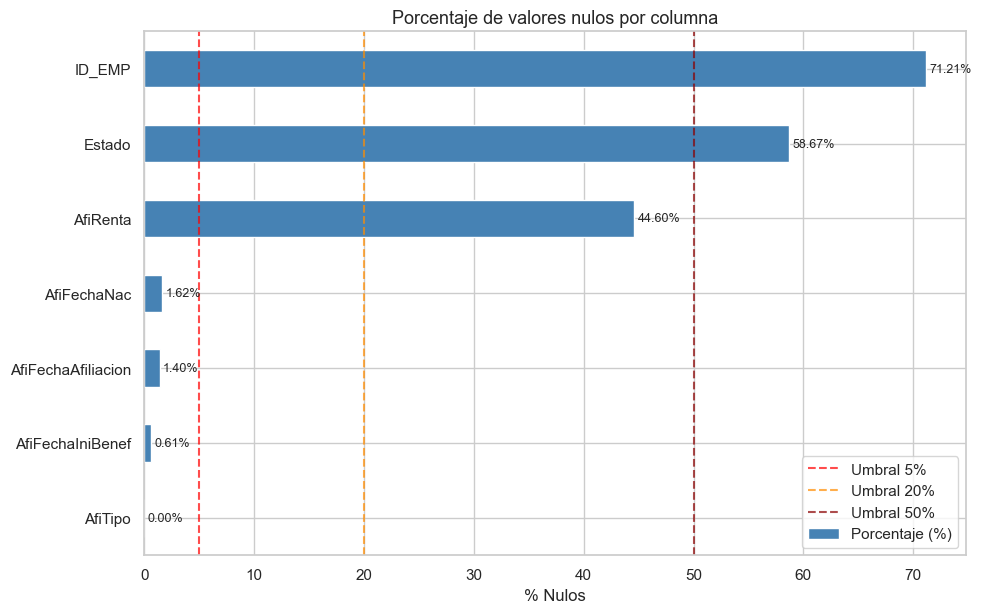

In [8]:
cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()

if cols_con_nulos:
    fig, ax = plt.subplots(figsize=(10, max(4, len(cols_con_nulos) * 0.9)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5,  color='red',        linestyle='--', alpha=0.7, label='Umbral 5%')
    ax.axvline(20, color='darkorange', linestyle='--', alpha=0.7, label='Umbral 20%')
    ax.axvline(50, color='darkred',    linestyle='--', alpha=0.7, label='Umbral 50%')
    ax.legend()
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}%',
                    (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

## 5. Estadísticas Descriptivas

In [9]:
print('=== Variables Numéricas — Estadísticas Descriptivas ===')
df[col_numericas].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas — Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
AfiRenta,168762.000000,316713.584948,356226.673007,1.000000,193935.000000,225181.000000,351940.000000,75612200.000000
Estado,125886.000000,330.193961,229.177540,1.000000,61.000000,408.000000,412.000000,1349.000000


In [10]:
# Estadísticas adicionales: asimetría, curtosis, ceros y negativos
stats_extra = pd.DataFrame({
    'Skewness'   : df[col_numericas].skew(),
    'Kurtosis'   : df[col_numericas].kurt(),
    'Ceros'      : (df[col_numericas] == 0).sum(),
    '% Ceros'    : ((df[col_numericas] == 0).sum() / len(df) * 100).round(2),
    'Negativos'  : (df[col_numericas] < 0).sum(),
    '% Negativos': ((df[col_numericas] < 0).sum() / len(df) * 100).round(2)
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,% Ceros,Negativos,% Negativos
AfiRenta,68.8342,"12,903.5544",0,0.0000,0,0.0000
Estado,0.3620,1.5701,0,0.0000,0,0.0000


## 6. Análisis de Variables Categóricas

In [11]:
# Cardinalidad y distribución de variables categóricas
cat_info = []
for c in col_categoricas:
    vc = df[c].value_counts(dropna=False)
    cat_info.append({
        'Columna'          : c,
        'Valores únicos'   : df[c].nunique(),
        'Valor más frecuente': vc.index[0] if len(vc) > 0 else 'N/A',
        'Frecuencia moda'  : vc.iloc[0] if len(vc) > 0 else 0,
        '% Moda'           : round(vc.iloc[0] / len(df) * 100, 2) if len(vc) > 0 else 0
    })

cardinalidad = pd.DataFrame(cat_info).set_index('Columna').sort_values('Valores únicos', ascending=False)
print('=== Cardinalidad de Variables Categóricas ===')
display(cardinalidad)

=== Cardinalidad de Variables Categóricas ===


,Valores únicos,Valor más frecuente,Frecuencia moda,% Moda
Columna,,,,
ID_AFI,304611,AFI_01047912,1,0.0000
ID_EMP,30,NaN,216915,71.2100
AfiTipo,1,P,304610,100.0000


=== Distribución AfiTipo ===


,Frecuencia,% Total
AfiTipo,,
P,304610,100.0000
NaN,1,0.0000


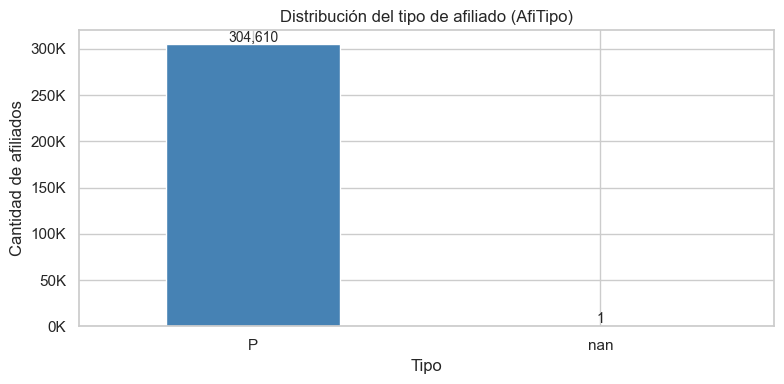

In [12]:
# AfiTipo: distribución del tipo de afiliado
if 'AfiTipo' in df.columns:
    vc_tipo = df['AfiTipo'].value_counts(dropna=False)
    print('=== Distribución AfiTipo ===')
    display(vc_tipo.to_frame('Frecuencia').assign(**{'% Total': lambda x: (x['Frecuencia'] / len(df) * 100).round(2)}))

    fig, ax = plt.subplots(figsize=(8, 4))
    vc_tipo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Distribución del tipo de afiliado (AfiTipo)')
    ax.set_xlabel('Tipo')
    ax.set_ylabel('Cantidad de afiliados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Valores únicos en Estado (incluyendo nulos): 100
Registros con Estado nulo: 178,725 (58.67%)


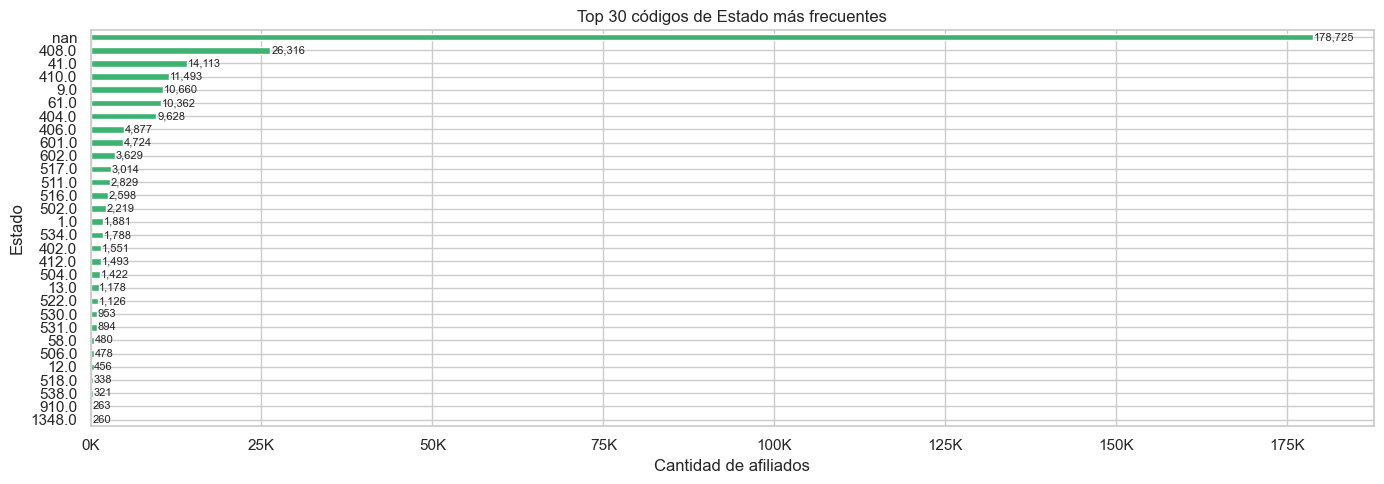


=== Top 30 estados ===


,Frecuencia,% Total
Estado,,
NaN,178725,58.6700
408.0000,26316,8.6400
41.0000,14113,4.6300
410.0000,11493,3.7700
9.0000,10660,3.5000
61.0000,10362,3.4000
404.0000,9628,3.1600
406.0000,4877,1.6000
601.0000,4724,1.5500


In [13]:
# Estado: distribución del código de estado del afiliado
if 'Estado' in df.columns:
    estado_counts = df['Estado'].value_counts(dropna=False).head(30)

    print(f'Valores únicos en Estado (incluyendo nulos): {df["Estado"].nunique(dropna=False)}')
    print(f'Registros con Estado nulo: {df["Estado"].isnull().sum():,} ({df["Estado"].isnull().sum()/len(df)*100:.2f}%)')

    fig, ax = plt.subplots(figsize=(14, 5))
    estado_counts.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Top 30 códigos de Estado más frecuentes', fontsize=12)
    ax.set_xlabel('Cantidad de afiliados')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}',
                    (p.get_width() + 100, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('\n=== Top 30 estados ===')
    display(estado_counts.to_frame('Frecuencia').assign(
        **{'% Total': lambda x: (x['Frecuencia'] / len(df) * 100).round(2)}
    ))

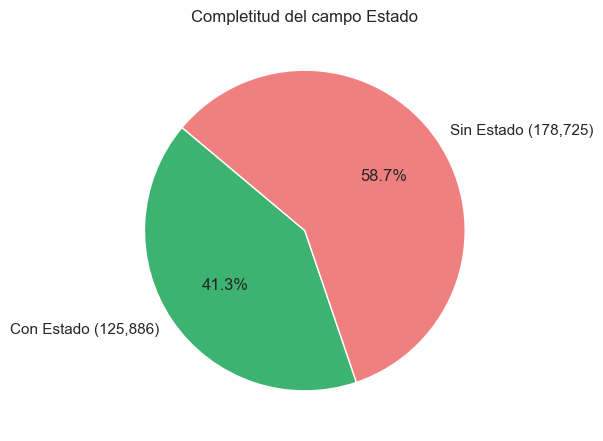

In [14]:
# Presencia vs ausencia de Estado (nulos vs registrados)
if 'Estado' in df.columns:
    con_estado    = df['Estado'].notna().sum()
    sin_estado    = df['Estado'].isna().sum()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        [con_estado, sin_estado],
        labels=[f'Con Estado ({con_estado:,})', f'Sin Estado ({sin_estado:,})'],
        autopct='%1.1f%%',
        colors=['mediumseagreen', 'lightcoral'],
        startangle=140
    )
    ax.set_title('Completitud del campo Estado')
    plt.tight_layout()
    plt.show()

Empleadores únicos (ID_EMP): 30
Registros sin empleador (ID_EMP nulo): 216,915 (71.21%)


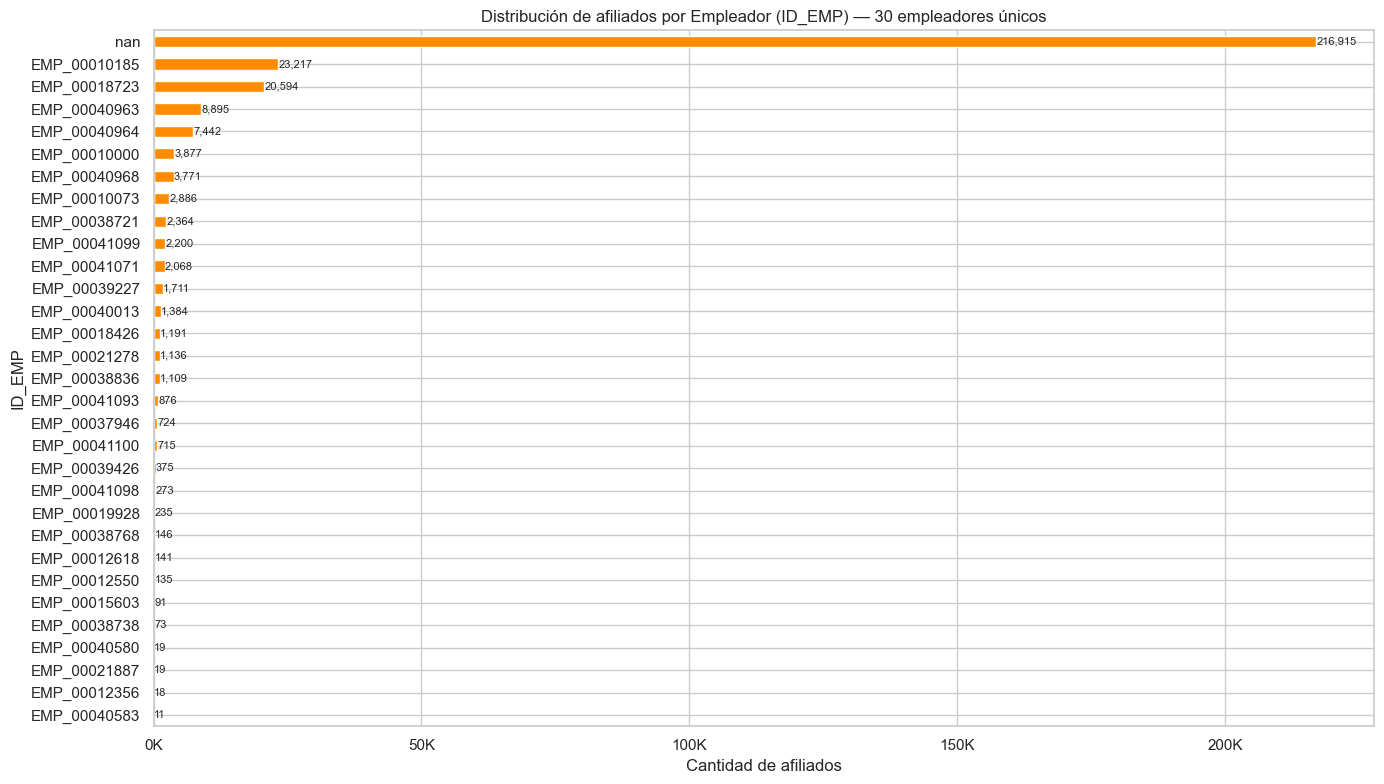


=== Afiliados por empleador ===


,Afiliados,% del total con empleador
ID_EMP,,
NaN,216915,71.2100
EMP_00010185,23217,7.6200
EMP_00018723,20594,6.7600
EMP_00040963,8895,2.9200
EMP_00040964,7442,2.4400
EMP_00010000,3877,1.2700
EMP_00040968,3771,1.2400
EMP_00010073,2886,0.9500
EMP_00038721,2364,0.7800


In [15]:
# ID_EMP: distribución de afiliados por empleador
if 'ID_EMP' in df.columns:
    emp_counts = df['ID_EMP'].value_counts(dropna=False)
    n_emp = df['ID_EMP'].nunique()

    print(f'Empleadores únicos (ID_EMP): {n_emp}')
    print(f'Registros sin empleador (ID_EMP nulo): {df["ID_EMP"].isnull().sum():,} ({df["ID_EMP"].isnull().sum()/len(df)*100:.2f}%)')

    emp_no_null = emp_counts.dropna().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(14, 8))
    emp_no_null.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title(f'Distribución de afiliados por Empleador (ID_EMP) — {n_emp} empleadores únicos', fontsize=12)
    ax.set_xlabel('Cantidad de afiliados')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}',
                    (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('\n=== Afiliados por empleador ===')
    display(emp_counts.dropna().to_frame('Afiliados').assign(
        **{'% del total con empleador': lambda x: (x['Afiliados'] / emp_counts.dropna().sum() * 100).round(2)}
    ))

## 7. Análisis de la Variable Numérica — AfiRenta

In [16]:
if 'AfiRenta' in df.columns:
    datos_renta = df['AfiRenta'].dropna()

    print('=== Estadísticas descriptivas de AfiRenta ===')
    print(datos_renta.describe().to_string())
    print(f'\nNulos  : {df["AfiRenta"].isnull().sum():,} ({df["AfiRenta"].isnull().sum()/len(df)*100:.2f}%)')
    print(f'Ceros  : {(datos_renta == 0).sum():,} ({(datos_renta == 0).sum()/len(datos_renta)*100:.2f}%)')
    print(f'Negativos: {(datos_renta < 0).sum():,}')
    print(f'Skewness : {datos_renta.skew():.4f}')
    print(f'Kurtosis : {datos_renta.kurt():.4f}')

=== Estadísticas descriptivas de AfiRenta ===
count      168,762.0000
mean       316,713.5849
std        356,226.6730
min              1.0000
25%        193,935.0000
50%        225,181.0000
75%        351,940.0000
max     75,612,200.0000

Nulos  : 135,849 (44.60%)
Ceros  : 0 (0.00%)
Negativos: 0
Skewness : 68.8342
Kurtosis : 12903.5544


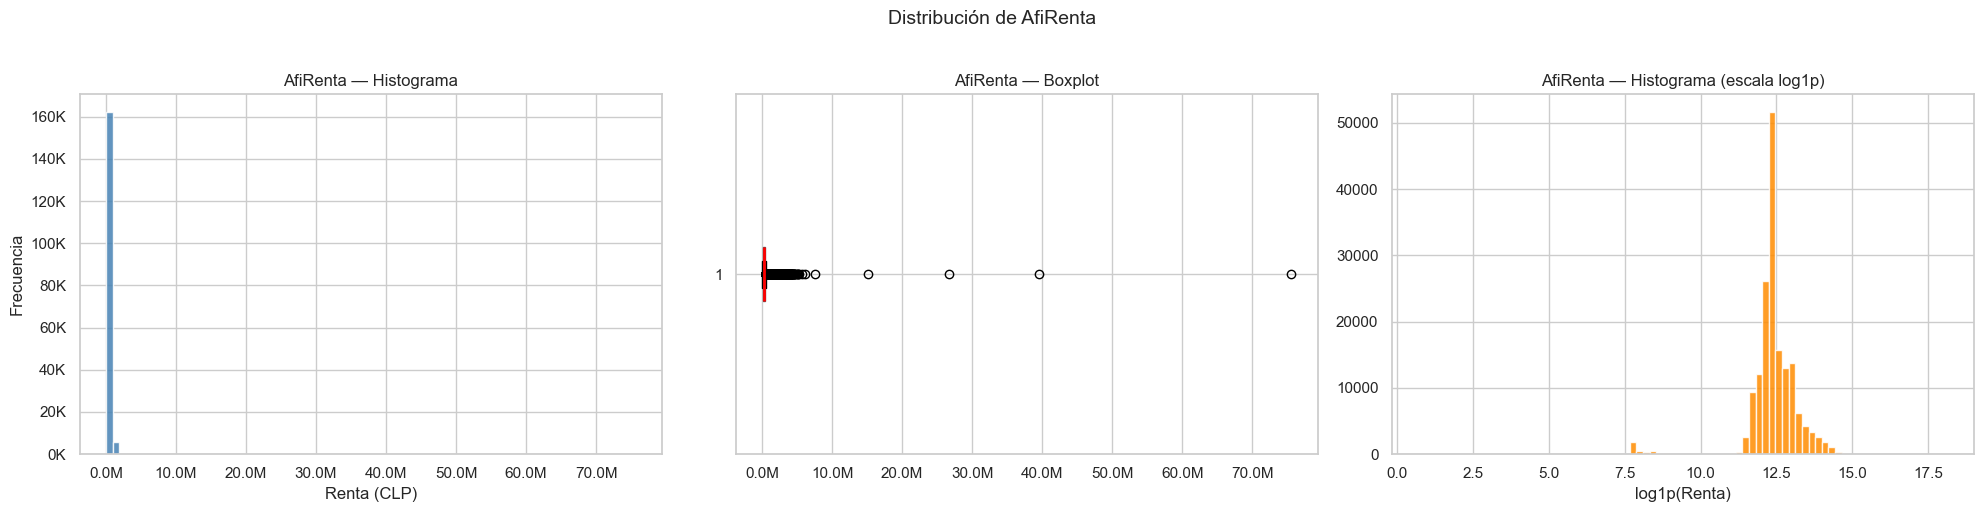

In [17]:
if 'AfiRenta' in df.columns:
    datos_renta = df['AfiRenta'].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Histograma (escala lineal)
    axes[0].hist(datos_renta, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title('AfiRenta — Histograma')
    axes[0].set_xlabel('Renta (CLP)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

    # Boxplot
    axes[1].boxplot(datos_renta, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('AfiRenta — Boxplot')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Histograma escala logarítmica (log1p)
    datos_pos = datos_renta[datos_renta > 0]
    axes[2].hist(np.log1p(datos_pos), bins=80, color='darkorange', edgecolor='white', alpha=0.85)
    axes[2].set_title('AfiRenta — Histograma (escala log1p)')
    axes[2].set_xlabel('log1p(Renta)')

    plt.suptitle('Distribución de AfiRenta', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

=== Percentiles clave de AfiRenta ===


,AfiRenta (CLP)
Percentil,
p1,"2,500"
p5,"110,201"
p10,"137,751"
p25,"193,935"
p50,"225,181"
p75,"351,940"
p90,"550,802"
p95,"822,041"
p99,"1,508,132"


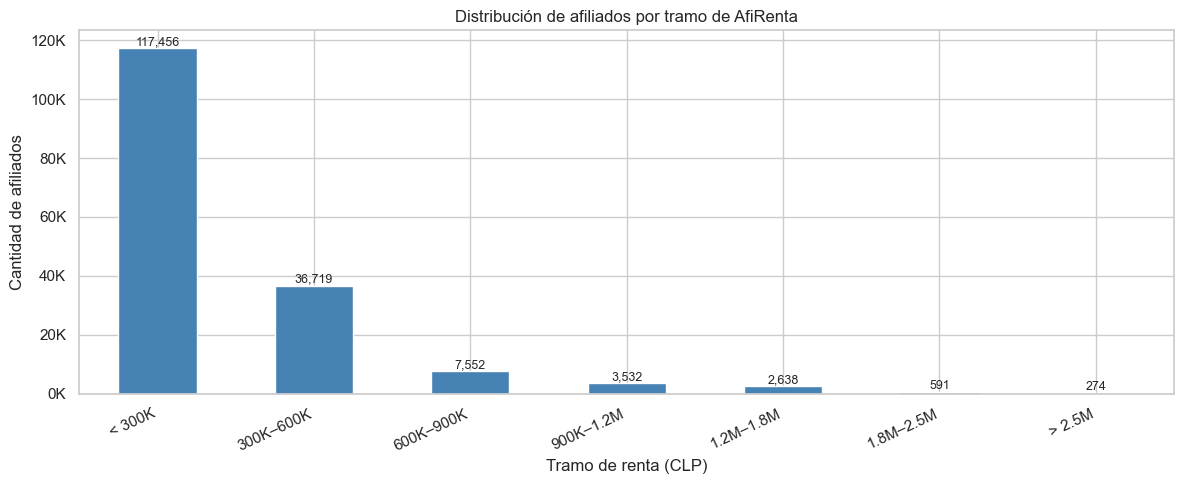

In [18]:
if 'AfiRenta' in df.columns:
    datos_renta = df['AfiRenta'].dropna()

    # Percentiles clave
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    perc_vals   = np.percentile(datos_renta, percentiles)

    perc_df = pd.DataFrame({'Percentil': [f'p{p}' for p in percentiles], 'AfiRenta (CLP)': perc_vals})
    print('=== Percentiles clave de AfiRenta ===')
    display(perc_df.set_index('Percentil').style.format('{:,.0f}'))

    # Distribución por tramos de renta
    bins   = [0, 300_000, 600_000, 900_000, 1_200_000, 1_800_000, 2_500_000, float('inf')]
    labels = ['< 300K', '300K–600K', '600K–900K', '900K–1.2M',
               '1.2M–1.8M', '1.8M–2.5M', '> 2.5M']

    df_renta_v = df['AfiRenta'].dropna().copy()
    tramos = pd.cut(df_renta_v, bins=bins, labels=labels, right=False)
    tramo_counts = tramos.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    tramo_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Distribución de afiliados por tramo de AfiRenta', fontsize=12)
    ax.set_xlabel('Tramo de renta (CLP)')
    ax.set_ylabel('Cantidad de afiliados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Análisis de Fechas y Variables Derivadas

In [19]:
# Cobertura temporal de cada columna de fecha
for col_fecha in col_fechas:
    datos_fecha = df[col_fecha].dropna()
    print(f'{col_fecha}:')
    print(f'  Nulos  : {df[col_fecha].isnull().sum():,} ({df[col_fecha].isnull().sum()/len(df)*100:.2f}%)')
    print(f'  Mínimo : {datos_fecha.min().date()}')
    print(f'  Máximo : {datos_fecha.max().date()}')
    print(f'  Rango  : {(datos_fecha.max() - datos_fecha.min()).days} días')
    print()

AfiFechaNac:
  Nulos  : 4,936 (1.62%)
  Mínimo : 1852-09-23
  Máximo : 2029-12-31
  Rango  : 64747 días

AfiFechaAfiliacion:
  Nulos  : 4,276 (1.40%)
  Mínimo : 1969-09-01
  Máximo : 2026-01-01
  Rango  : 20576 días

AfiFechaIniBenef:
  Nulos  : 1,872 (0.61%)
  Mínimo : 1998-10-01
  Máximo : 2026-03-01
  Rango  : 10013 días



=== Estadísticas de Edad (años) ===
count   299,660.0000
mean         73.8083
std          12.0210
min           0.6000
25%          68.0000
50%          74.1000
75%          81.3000
max         126.3000


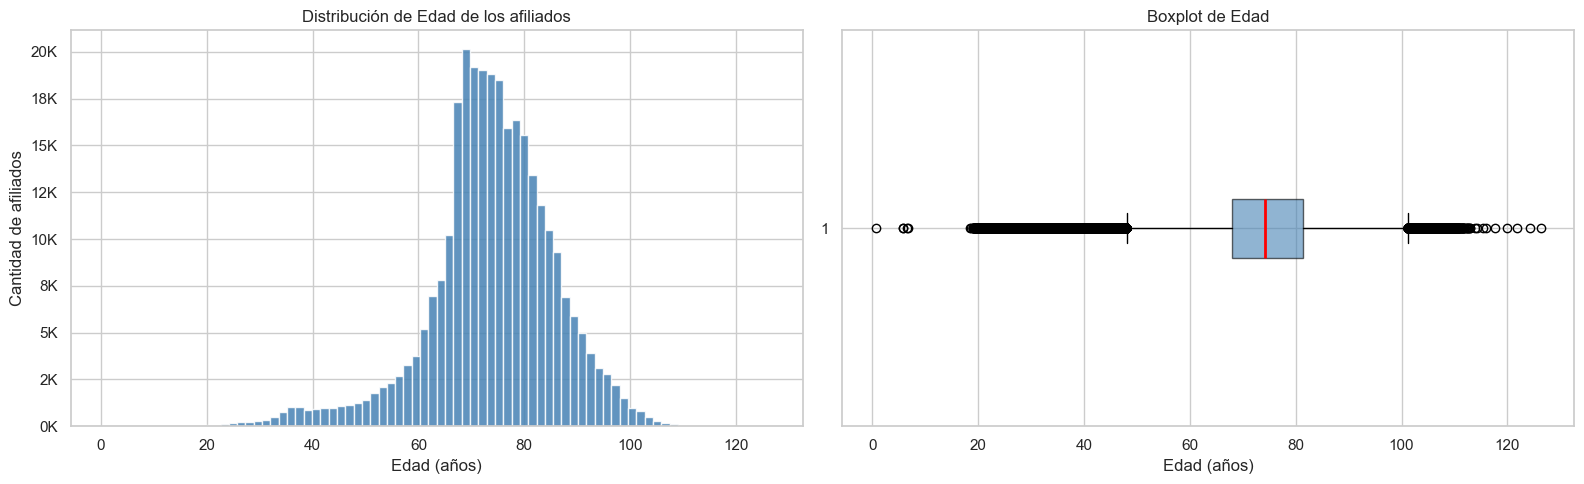

In [20]:
# ── EDAD DEL AFILIADO ──
FECHA_HOY = pd.Timestamp('today').normalize()

if 'AfiFechaNac' in df.columns:
    df['Edad'] = ((FECHA_HOY - df['AfiFechaNac']).dt.days / 365.25).round(1)

    edad_valida = df['Edad'].dropna()
    edad_valida = edad_valida[(edad_valida >= 0) & (edad_valida <= 130)]

    print('=== Estadísticas de Edad (años) ===')
    print(edad_valida.describe().to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(edad_valida, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribución de Edad de los afiliados')
    axes[0].set_xlabel('Edad (años)')
    axes[0].set_ylabel('Cantidad de afiliados')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

    axes[1].boxplot(edad_valida, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Boxplot de Edad')
    axes[1].set_xlabel('Edad (años)')

    plt.tight_layout()
    plt.show()

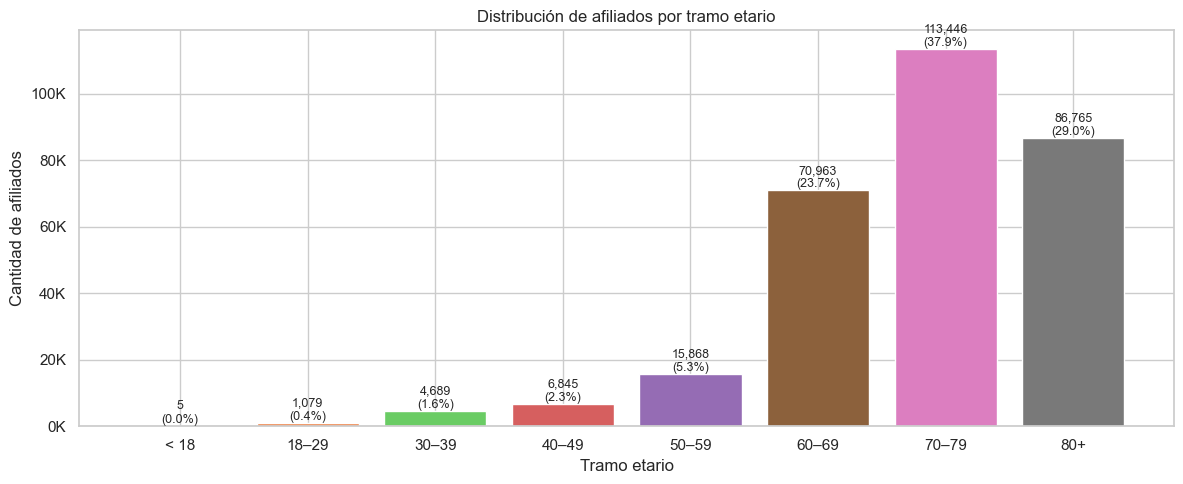

In [21]:
# Distribución de afiliados por tramo etario
if 'Edad' in df.columns:
    bins_edad   = [0, 18, 30, 40, 50, 60, 70, 80, 130]
    labels_edad = ['< 18', '18–29', '30–39', '40–49', '50–59', '60–69', '70–79', '80+']

    df_edad_v = df['Edad'].dropna()
    df_edad_v = df_edad_v[(df_edad_v >= 0) & (df_edad_v <= 130)]

    tramos_edad = pd.cut(df_edad_v, bins=bins_edad, labels=labels_edad, right=False)
    tramo_counts_edad = tramos_edad.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    colores_edad = sns.color_palette('muted', len(tramo_counts_edad))
    bars = ax.bar(tramo_counts_edad.index.astype(str), tramo_counts_edad.values,
                  color=colores_edad, edgecolor='white')
    ax.set_title('Distribución de afiliados por tramo etario', fontsize=12)
    ax.set_xlabel('Tramo etario')
    ax.set_ylabel('Cantidad de afiliados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    for bar, val in zip(bars, tramo_counts_edad.values):
        pct = val / df_edad_v.shape[0] * 100
        ax.annotate(f'{val:,}\n({pct:.1f}%)',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

In [22]:
# Afiliados con edades fuera de rango esperado
if 'Edad' in df.columns:
    df_edad_ok   = df['Edad'].dropna()
    muy_jovenes  = (df_edad_ok < 18).sum()
    muy_mayores  = (df_edad_ok > 100).sum()
    negativos    = (df_edad_ok < 0).sum()

    print(f'Edades < 0 (fecha nac futura)  : {negativos:,}')
    print(f'Edades < 18 (menores de edad)  : {muy_jovenes:,} ({muy_jovenes/len(df_edad_ok)*100:.2f}%)')
    print(f'Edades > 100 (posibles errores): {muy_mayores:,} ({muy_mayores/len(df_edad_ok)*100:.2f}%)')

    if muy_mayores > 0:
        print('\n=== Muestra de afiliados con Edad > 100 ===')
        display(df[df['Edad'] > 100][['ID_AFI', 'AfiFechaNac', 'Edad', 'AfiTipo', 'Estado']].head(10))

Edades < 0 (fecha nac futura)  : 13
Edades < 18 (menores de edad)  : 18 (0.01%)
Edades > 100 (posibles errores): 2,567 (0.86%)

=== Muestra de afiliados con Edad > 100 ===


,ID_AFI,AfiFechaNac,Edad,AfiTipo,Estado
31,AFI_00918978,1925-11-03,100.5000,P,NaN
39,AFI_01024606,1924-10-16,101.5000,P,NaN
46,AFI_01039144,1926-03-01,100.2000,P,NaN
71,AFI_01057208,1925-10-07,100.6000,P,NaN
87,AFI_00242575,1922-01-20,104.3000,P,NaN
94,AFI_00936744,1925-10-04,100.6000,P,NaN
147,AFI_00243808,1923-03-10,103.1000,P,NaN
214,AFI_00936766,1925-11-08,100.5000,P,NaN
221,AFI_01032688,1924-12-12,101.4000,P,NaN
225,AFI_01038826,1924-08-27,101.7000,P,NaN


=== Antigüedad de afiliación (años) ===
count   300,335.0000
mean          7.1399
std           5.7621
min           0.3300
25%           1.9100
50%           6.4100
75%          11.2400
max          56.6600


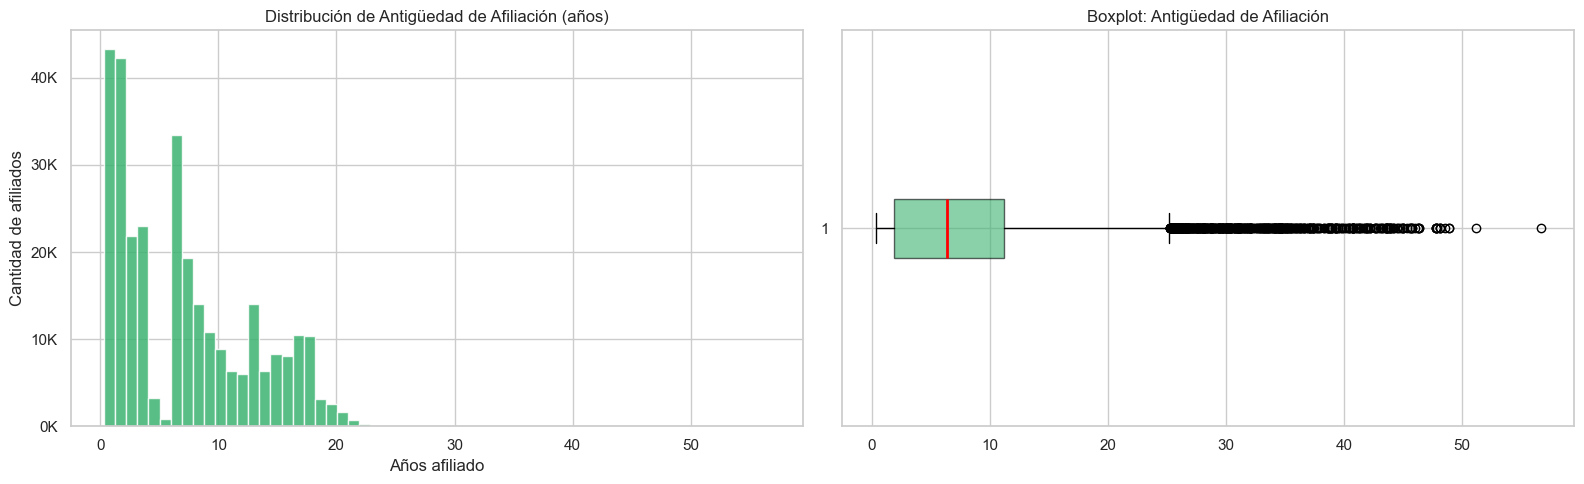


Registros con AfiFechaAfiliacion en el futuro: 0 (0.00%)


In [23]:
# ── ANTIGÜEDAD DE AFILIACIÓN ──
if 'AfiFechaAfiliacion' in df.columns:
    df['AntiguedadAfil_Anios'] = ((FECHA_HOY - df['AfiFechaAfiliacion']).dt.days / 365.25).round(2)

    antg_valida = df['AntiguedadAfil_Anios'].dropna()
    antg_valida = antg_valida[antg_valida >= 0]

    print('=== Antigüedad de afiliación (años) ===')
    print(antg_valida.describe().to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(antg_valida, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[0].set_title('Distribución de Antigüedad de Afiliación (años)')
    axes[0].set_xlabel('Años afiliado')
    axes[0].set_ylabel('Cantidad de afiliados')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

    axes[1].boxplot(antg_valida, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Boxplot: Antigüedad de Afiliación')

    plt.tight_layout()
    plt.show()

    # Afiliaciones con fecha futura (dato anómalo)
    futuros = (df['AfiFechaAfiliacion'] > FECHA_HOY).sum()
    print(f'\nRegistros con AfiFechaAfiliacion en el futuro: {futuros:,} ({futuros/len(df)*100:.2f}%)')
    if futuros > 0:
        display(df[df['AfiFechaAfiliacion'] > FECHA_HOY][['ID_AFI', 'AfiFechaAfiliacion', 'AfiTipo', 'Estado']].head(10))

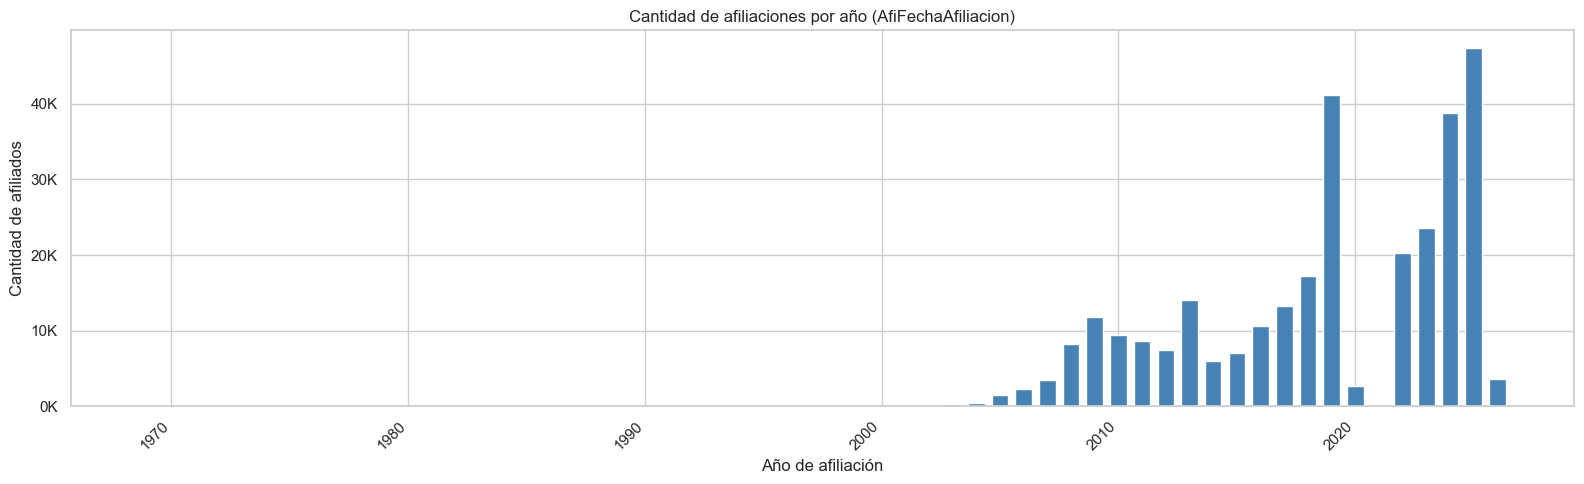

=== Afiliaciones por año ===


,Afiliados,% del total
AnioAfiliacion,,
"1,969.0000",1,0.0000
"1,975.0000",1,0.0000
"1,977.0000",3,0.0000
"1,978.0000",8,0.0000
"1,980.0000",10,0.0000
"1,981.0000",8,0.0000
"1,982.0000",17,0.0100
"1,983.0000",9,0.0000
"1,984.0000",12,0.0000


In [24]:
# Afiliaciones por año (AfiFechaAfiliacion)
if 'AfiFechaAfiliacion' in df.columns:
    df['AnioAfiliacion'] = df['AfiFechaAfiliacion'].dt.year

    afil_x_anio = df['AnioAfiliacion'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(afil_x_anio.index, afil_x_anio.values, color='steelblue', edgecolor='white', width=0.7)
    ax.set_title('Cantidad de afiliaciones por año (AfiFechaAfiliacion)', fontsize=12)
    ax.set_xlabel('Año de afiliación')
    ax.set_ylabel('Cantidad de afiliados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('=== Afiliaciones por año ===')
    display(afil_x_anio.to_frame('Afiliados').assign(**{'% del total': lambda x: (x['Afiliados'] / len(df) * 100).round(2)}))

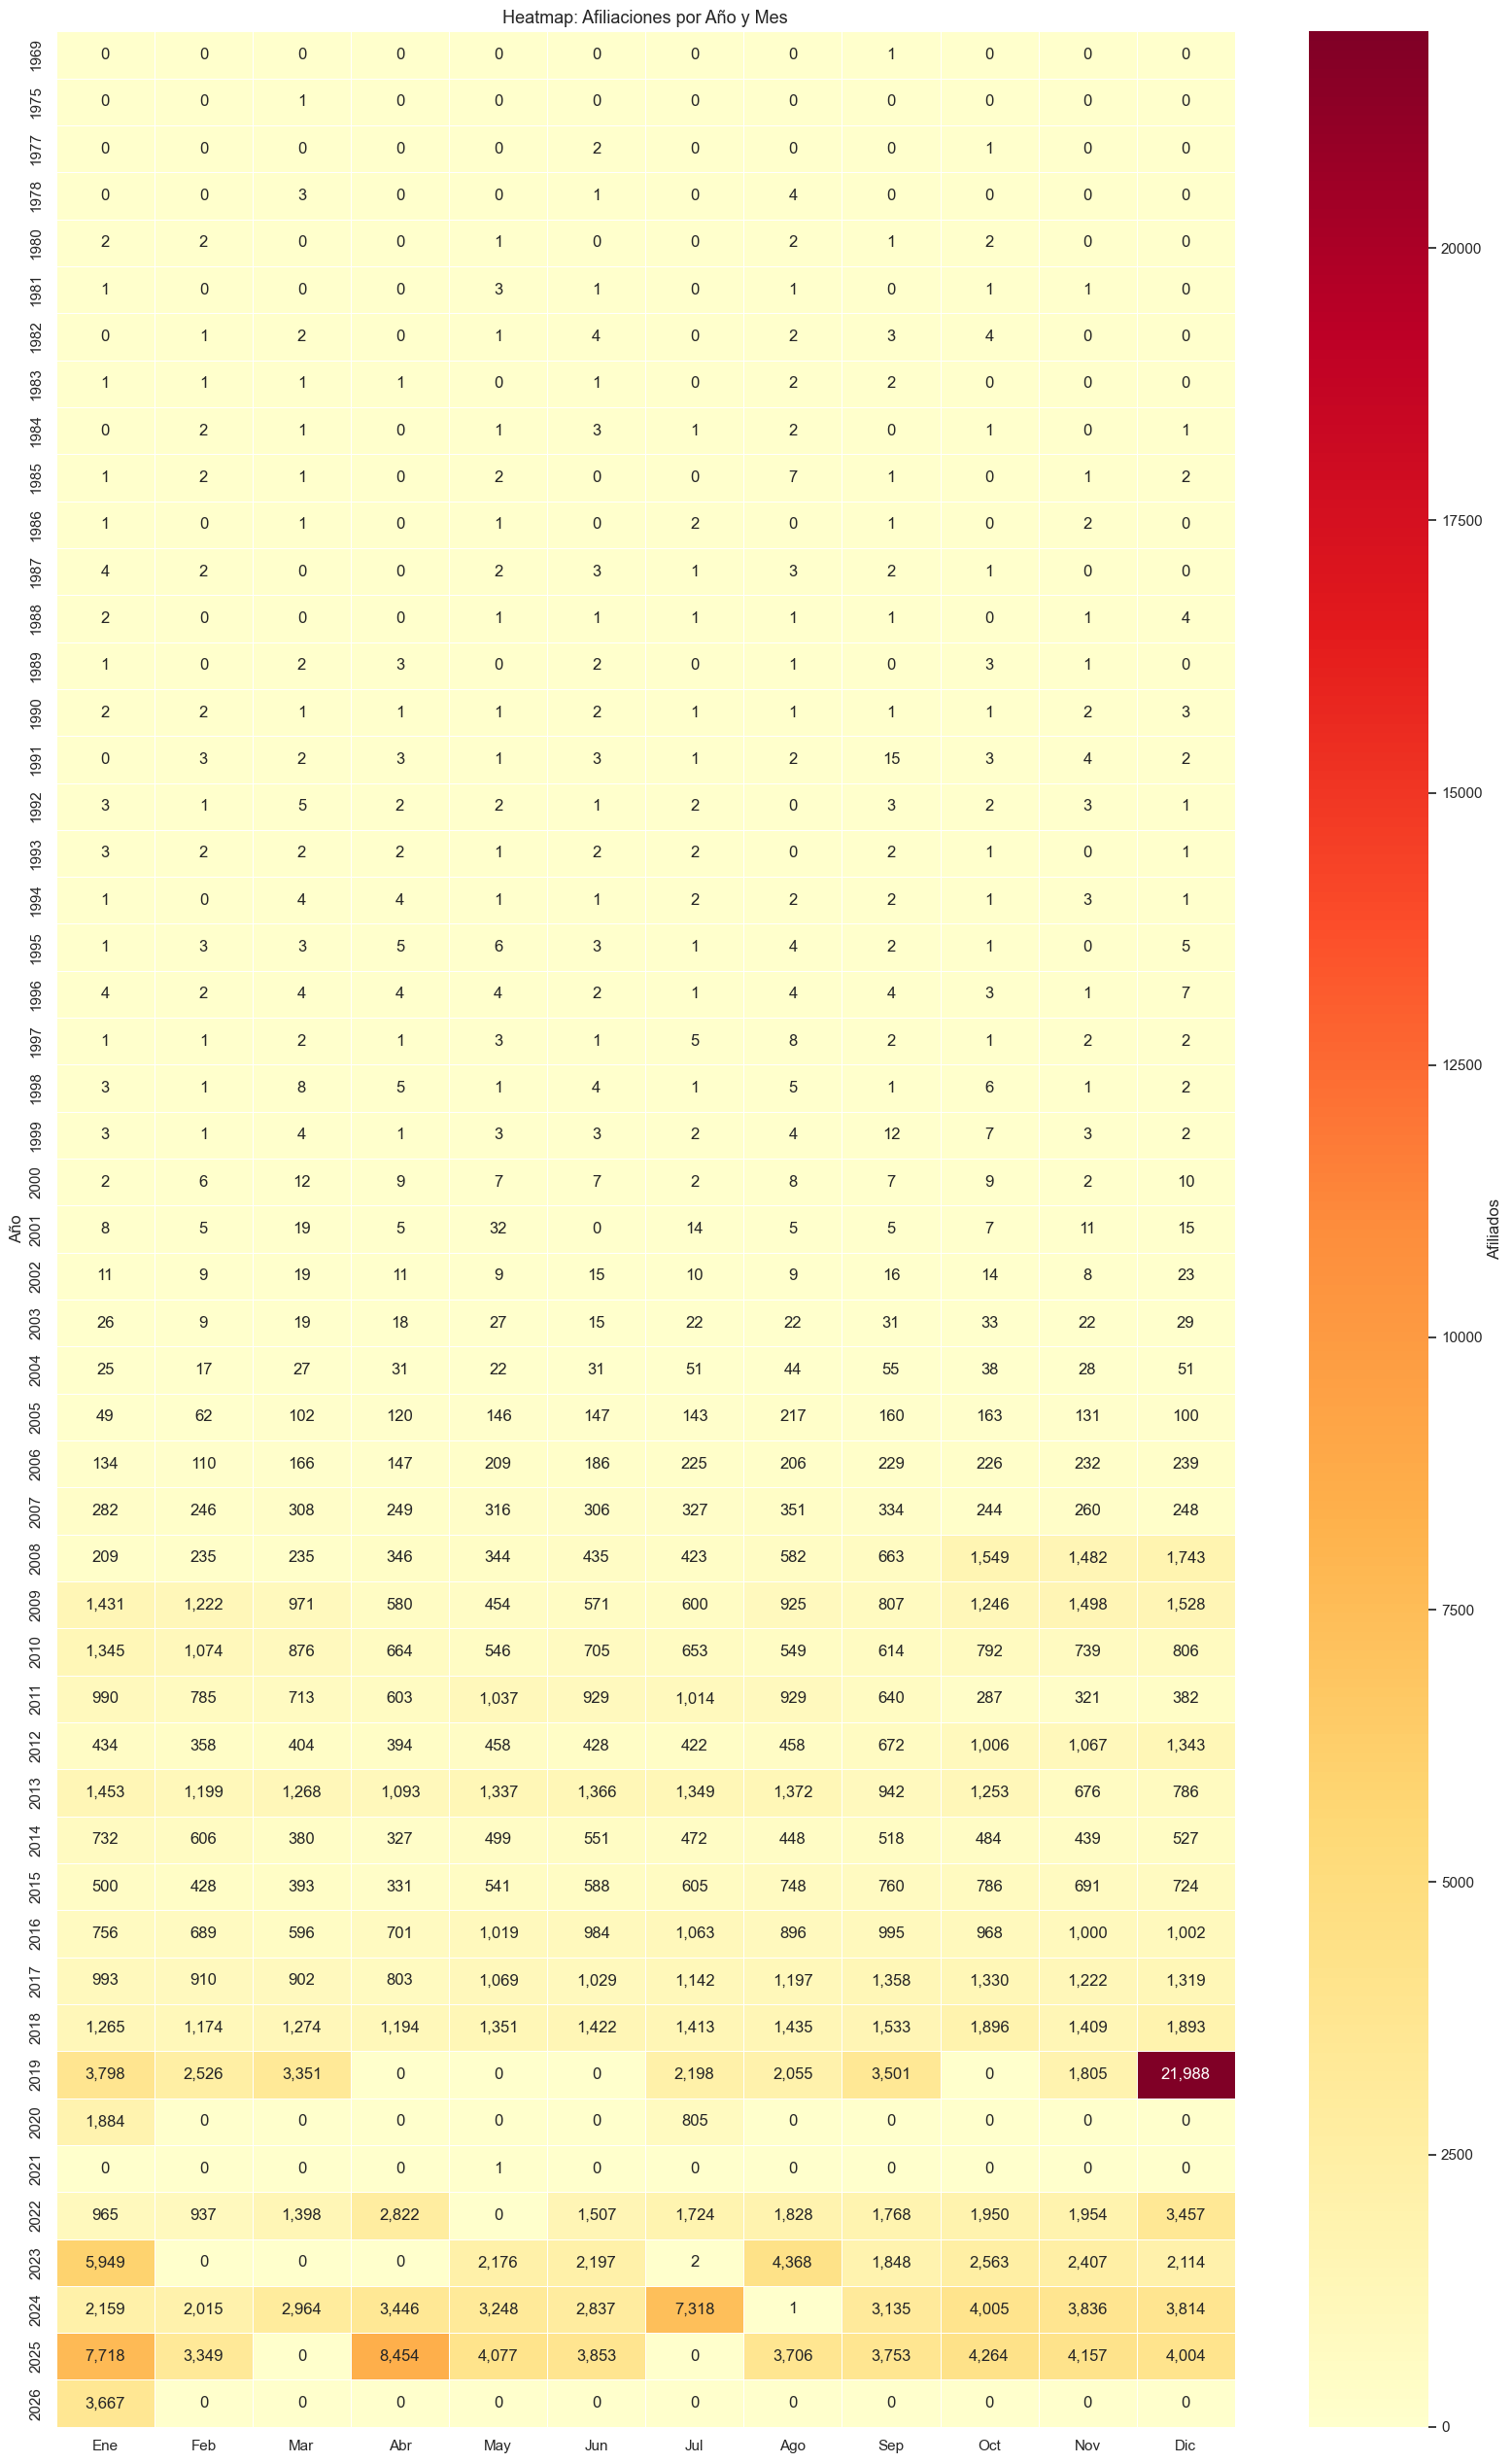

In [25]:
# Heatmap: afiliaciones por año y mes
if 'AfiFechaAfiliacion' in df.columns:
    df_hm = df.dropna(subset=['AfiFechaAfiliacion']).copy()
    df_hm['Anio_Afil'] = df_hm['AfiFechaAfiliacion'].dt.year
    df_hm['Mes_Afil']  = df_hm['AfiFechaAfiliacion'].dt.month

    pivot = df_hm.groupby(['Anio_Afil', 'Mes_Afil']).size().unstack(fill_value=0)
    pivot.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'][:pivot.shape[1]]

    fig, ax = plt.subplots(figsize=(16, max(4, pivot.shape[0] * 0.5)))
    sns.heatmap(pivot, annot=True, fmt=',d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Afiliados'})
    ax.set_title('Heatmap: Afiliaciones por Año y Mes', fontsize=13)
    ax.set_ylabel('Año')
    plt.tight_layout()
    plt.show()

Inicio de beneficios:
  Mínimo: 1998-10-01
  Máximo: 2026-03-01
  Nulos : 1,872 (0.61%)


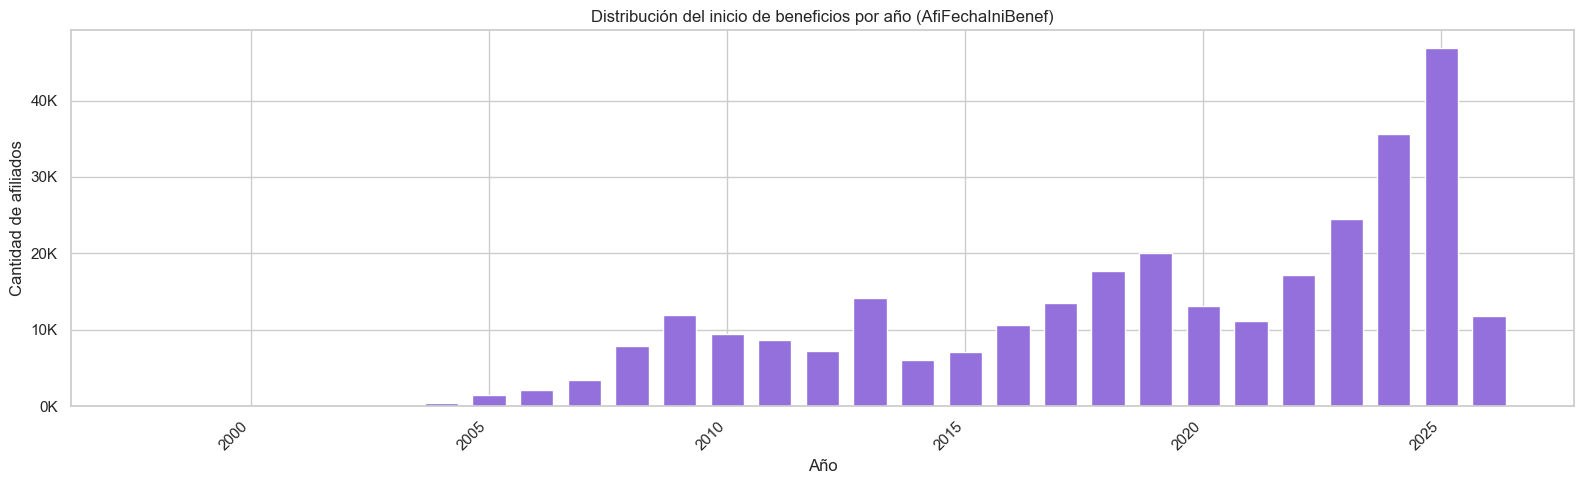


AfiFechaIniBenef en el futuro: 0 (0.00%)


In [26]:
# ── INICIO DE BENEFICIOS ──
if 'AfiFechaIniBenef' in df.columns:
    df['AnioIniBenef'] = df['AfiFechaIniBenef'].dt.year

    benef_x_anio = df['AnioIniBenef'].value_counts().sort_index()

    print(f'Inicio de beneficios:')
    print(f'  Mínimo: {df["AfiFechaIniBenef"].min().date() if df["AfiFechaIniBenef"].notna().any() else "N/A"}')
    print(f'  Máximo: {df["AfiFechaIniBenef"].max().date() if df["AfiFechaIniBenef"].notna().any() else "N/A"}')
    print(f'  Nulos : {df["AfiFechaIniBenef"].isnull().sum():,} ({df["AfiFechaIniBenef"].isnull().sum()/len(df)*100:.2f}%)')

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(benef_x_anio.index, benef_x_anio.values, color='mediumpurple', edgecolor='white', width=0.7)
    ax.set_title('Distribución del inicio de beneficios por año (AfiFechaIniBenef)', fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de afiliados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Beneficios con inicio en el futuro (potencialmente válido pero destacable)
    futuros_benef = (df['AfiFechaIniBenef'] > FECHA_HOY).sum()
    print(f'\nAfiFechaIniBenef en el futuro: {futuros_benef:,} ({futuros_benef/len(df)*100:.2f}%)')

=== Diferencia (días) entre AfiFechaAfiliacion y AfiFechaIniBenef ===
count   300,335.0000
mean         85.0925
std         411.9267
min      -5,418.0000
25%           0.0000
50%          59.0000
75%          61.0000
max      15,097.0000

Registros donde beneficio inicia ANTES de la afiliación: 508
Registros donde beneficio inicia el mismo día            : 111,892
Registros donde beneficio inicia DESPUÉS de la afiliación: 187,935


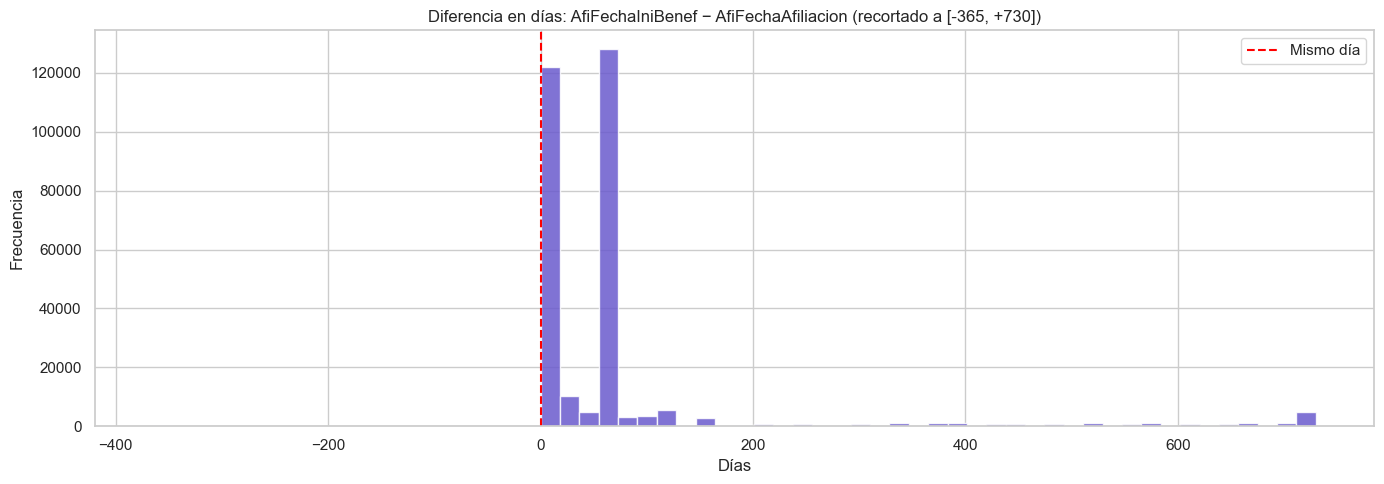

In [27]:
# Diferencia entre AfiFechaAfiliacion y AfiFechaIniBenef
if 'AfiFechaAfiliacion' in df.columns and 'AfiFechaIniBenef' in df.columns:
    df['DiasDiffAfil_Benef'] = (df['AfiFechaIniBenef'] - df['AfiFechaAfiliacion']).dt.days

    diff_valida = df['DiasDiffAfil_Benef'].dropna()

    print('=== Diferencia (días) entre AfiFechaAfiliacion y AfiFechaIniBenef ===')
    print(diff_valida.describe().to_string())
    print(f'\nRegistros donde beneficio inicia ANTES de la afiliación: {(diff_valida < 0).sum():,}')
    print(f'Registros donde beneficio inicia el mismo día            : {(diff_valida == 0).sum():,}')
    print(f'Registros donde beneficio inicia DESPUÉS de la afiliación: {(diff_valida > 0).sum():,}')

    fig, ax = plt.subplots(figsize=(14, 5))
    diff_clip = diff_valida.clip(-365, 730)
    ax.hist(diff_clip, bins=60, color='slateblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', label='Mismo día')
    ax.set_title('Diferencia en días: AfiFechaIniBenef − AfiFechaAfiliacion (recortado a [-365, +730])')
    ax.set_xlabel('Días')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Análisis Cruzado — Renta por Tramos y Variables Clave

=== AfiRenta promedio y mediana por ID_EMP ===


,Renta_Media,Renta_Mediana,N_Afiliados
ID_EMP,,,
EMP_00010073,"965,479","841,074","2,886"
EMP_00010000,"815,276","718,385","3,877"
EMP_00041098,"443,540","417,065",273
EMP_00040580,"436,739","397,329",19
EMP_00040013,"436,332","403,594","1,384"
EMP_00019928,"431,817","392,294",235
EMP_00038768,"428,520","379,050",146
EMP_00041071,"419,456","377,258","2,068"
EMP_00041100,"418,692","384,756",715


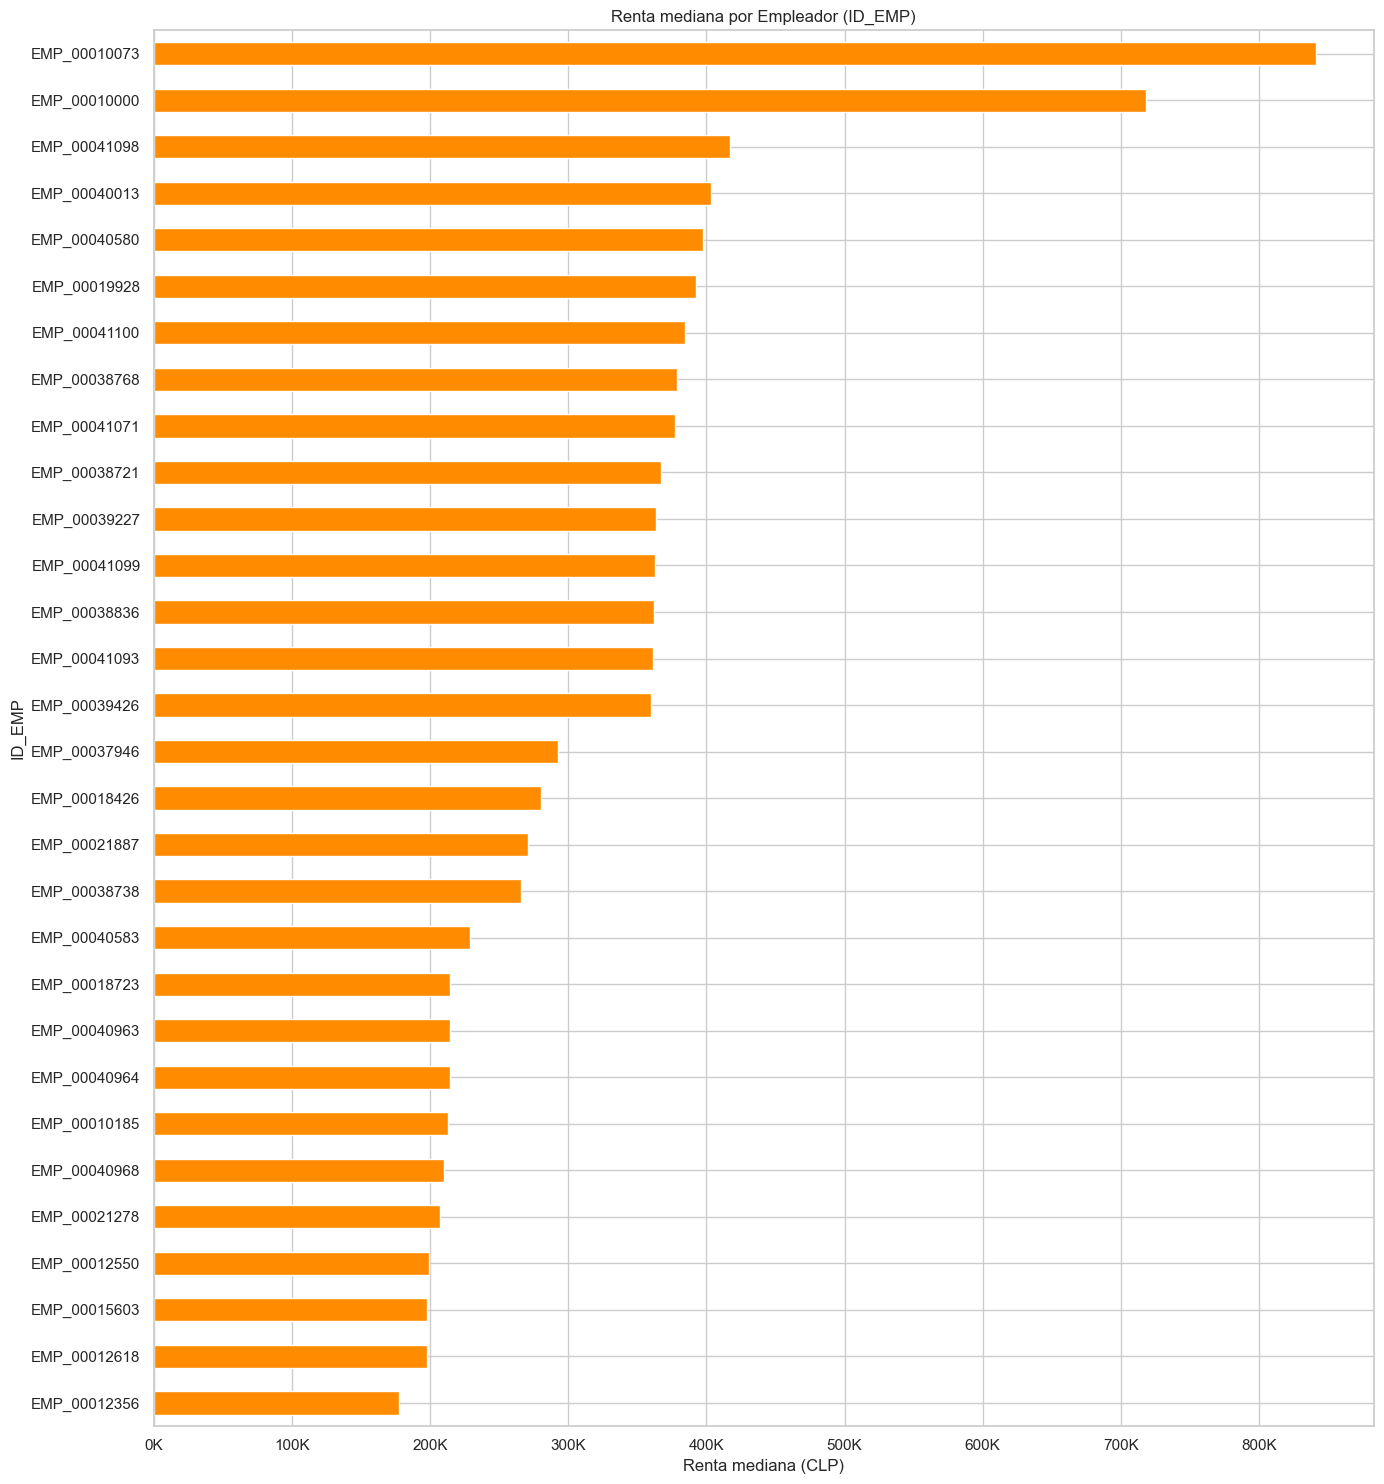

In [28]:
# AfiRenta por empleador (ID_EMP)
if 'AfiRenta' in df.columns and 'ID_EMP' in df.columns:
    renta_emp = df.dropna(subset=['AfiRenta', 'ID_EMP']) \
                  .groupby('ID_EMP')['AfiRenta'] \
                  .agg(['mean', 'median', 'count']) \
                  .rename(columns={'mean': 'Renta_Media', 'median': 'Renta_Mediana', 'count': 'N_Afiliados'}) \
                  .sort_values('Renta_Media', ascending=False)

    print('=== AfiRenta promedio y mediana por ID_EMP ===')
    display(renta_emp.style.format('{:,.0f}').background_gradient(cmap='Blues', subset=['Renta_Media']))

    fig, ax = plt.subplots(figsize=(14, max(4, len(renta_emp) * 0.5)))
    renta_emp['Renta_Mediana'].sort_values().plot(
        kind='barh', ax=ax, color='darkorange', edgecolor='white'
    )
    ax.set_title('Renta mediana por Empleador (ID_EMP)', fontsize=12)
    ax.set_xlabel('Renta mediana (CLP)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.tight_layout()
    plt.show()

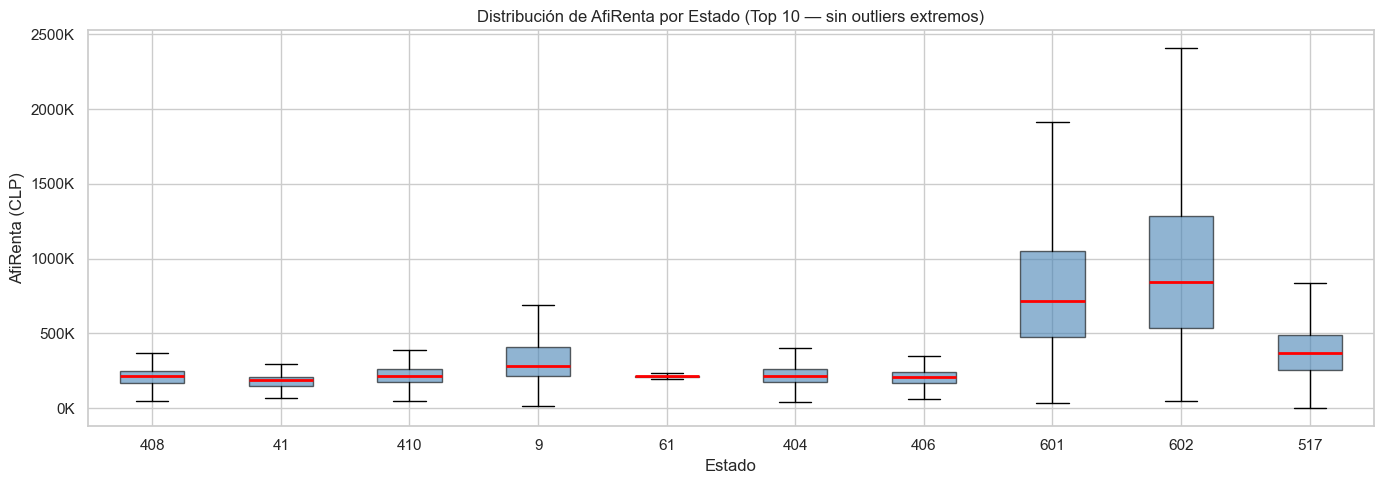

In [29]:
# AfiRenta por Estado (Top 10 estados más frecuentes)
if 'AfiRenta' in df.columns and 'Estado' in df.columns:
    top_estados = df['Estado'].value_counts().head(10).index.tolist()
    df_top_est  = df[df['Estado'].isin(top_estados) & df['AfiRenta'].notna()]

    grupos_est  = [df_top_est.loc[df_top_est['Estado'] == e, 'AfiRenta'].dropna() for e in top_estados]
    etiq_est    = [str(int(e)) for e in top_estados]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.boxplot(grupos_est, labels=etiq_est, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               showfliers=False)
    ax.set_title('Distribución de AfiRenta por Estado (Top 10 — sin outliers extremos)', fontsize=12)
    ax.set_xlabel('Estado')
    ax.set_ylabel('AfiRenta (CLP)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    plt.tight_layout()
    plt.show()

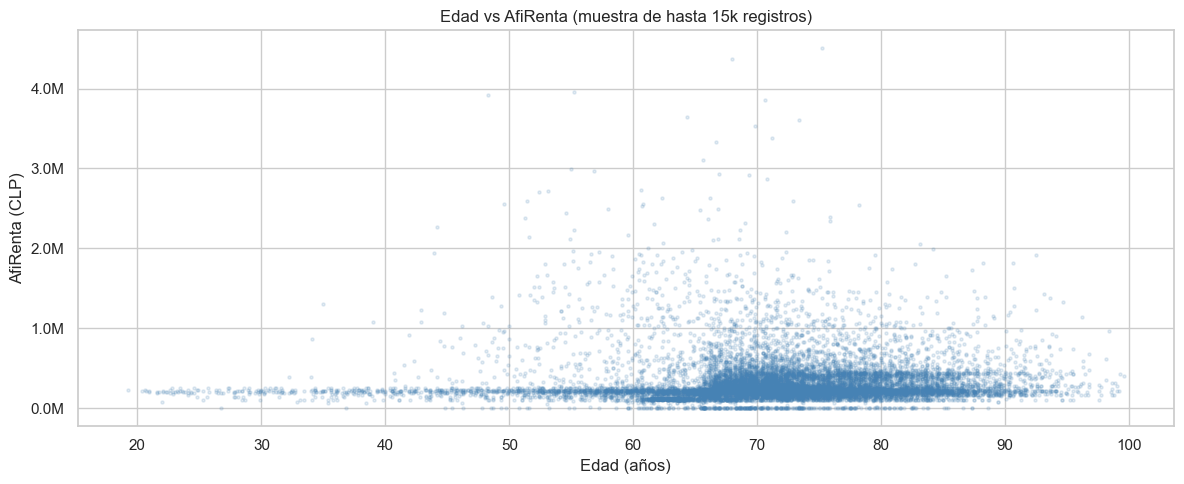

=== AfiRenta media y mediana por tramo etario ===


,Renta_Mediana,Renta_Media,N_Afiliados
TramEtario,,,
<18,"283,382","341,374",5
18-29,"214,296","204,235",921
30-39,"214,296","222,269","1,564"
40-49,"214,296","292,929","3,100"
50-59,"214,296","384,490","8,666"
60-69,"224,004","301,557","54,110"
70-79,"235,177","318,878","72,934"
80+,"248,260","331,158","27,439"


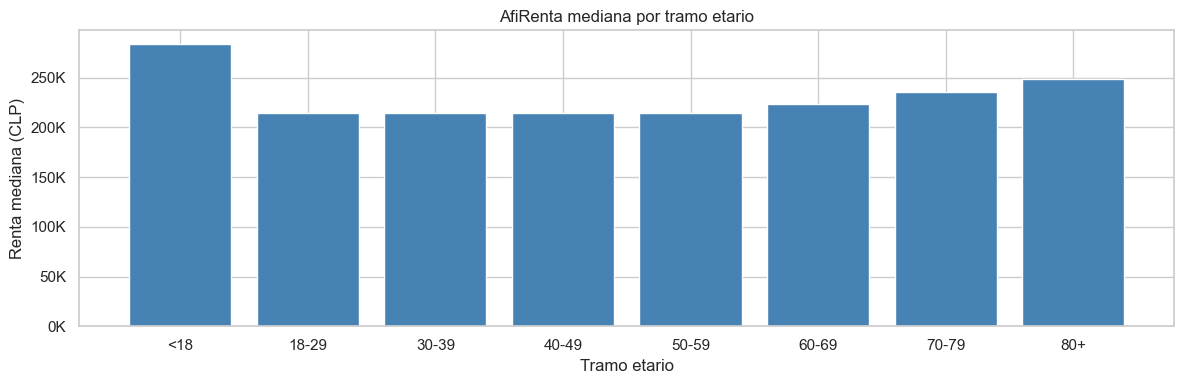

In [30]:
# Edad vs AfiRenta (scatter con muestra)
if 'Edad' in df.columns and 'AfiRenta' in df.columns:
    df_scatter = df[['Edad', 'AfiRenta']].dropna()
    df_scatter = df_scatter[(df_scatter['Edad'] >= 0) & (df_scatter['Edad'] <= 100)]
    muestra = df_scatter.sample(min(15_000, len(df_scatter)), random_state=42)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(muestra['Edad'], muestra['AfiRenta'],
               alpha=0.15, s=5, color='steelblue')
    ax.set_title('Edad vs AfiRenta (muestra de hasta 15k registros)', fontsize=12)
    ax.set_xlabel('Edad (años)')
    ax.set_ylabel('AfiRenta (CLP)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    plt.tight_layout()
    plt.show()

    # Renta mediana por tramo etario
    if 'Edad' in df.columns:
        bins_e   = [0, 18, 30, 40, 50, 60, 70, 80, 130]
        labels_e = ['<18', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
        df_ec    = df[['Edad', 'AfiRenta']].dropna().copy()
        df_ec    = df_ec[(df_ec['Edad'] >= 0) & (df_ec['Edad'] <= 130)]
        df_ec['TramEtario'] = pd.cut(df_ec['Edad'], bins=bins_e, labels=labels_e, right=False)

        renta_edad = df_ec.groupby('TramEtario', observed=True)['AfiRenta'].agg(['median', 'mean', 'count'])
        renta_edad.columns = ['Renta_Mediana', 'Renta_Media', 'N_Afiliados']

        print('=== AfiRenta media y mediana por tramo etario ===')
        display(renta_edad.style.format('{:,.0f}').background_gradient(cmap='Blues', subset=['Renta_Mediana']))

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.bar(renta_edad.index.astype(str), renta_edad['Renta_Mediana'],
               color='steelblue', edgecolor='white')
        ax.set_title('AfiRenta mediana por tramo etario', fontsize=12)
        ax.set_xlabel('Tramo etario')
        ax.set_ylabel('Renta mediana (CLP)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
        plt.tight_layout()
        plt.show()

## 10. Análisis de Correlaciones

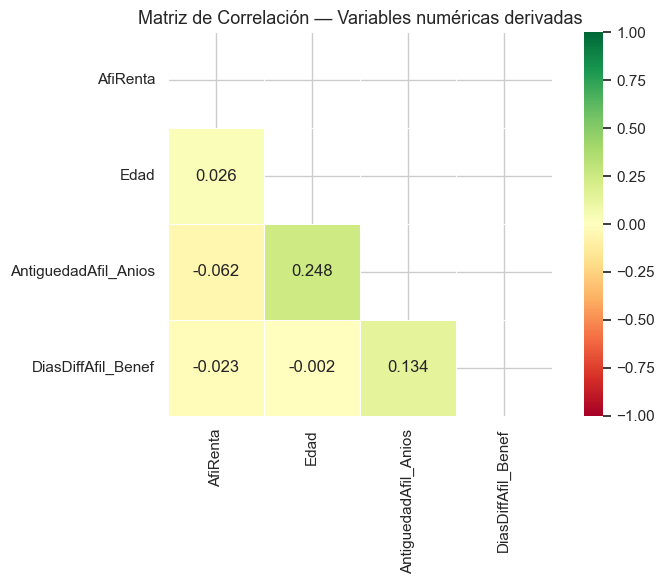

In [31]:
cols_corr = [c for c in ['AfiRenta', 'Edad', 'AntiguedadAfil_Anios', 'DiasDiffAfil_Benef'] if c in df.columns]

if len(cols_corr) > 1:
    corr_matrix = df[cols_corr].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title('Matriz de Correlación — Variables numéricas derivadas', fontsize=13)
    plt.tight_layout()
    plt.show()

## 11. Detección de Outliers

In [32]:
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna'          : nombre,
        'Q1'               : Q1,
        'Q3'               : Q3,
        'IQR'              : IQR,
        'Límite inferior'  : lower,
        'Límite superior'  : upper,
        'N° outliers'      : len(outliers),
        '% outliers'       : round(len(outliers) / len(serie) * 100, 2)
    }

cols_outlier = [c for c in ['AfiRenta', 'Edad', 'AntiguedadAfil_Anios'] if c in df.columns]
resumen_outliers = pd.DataFrame([
    detectar_outliers_iqr(df[c].dropna(), c) for c in cols_outlier
])

print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
AfiRenta,"193,935.00","351,940.00","158,005.00","-43,072.50","588,947.50","15,053.00",8.92
Edad,67.90,81.30,13.40,47.80,101.40,"12,704.00",4.24
AntiguedadAfil_Anios,1.91,11.24,9.33,-12.09,25.23,539.00,0.18


In [33]:
# Detalle de outliers extremos en AfiRenta
if 'AfiRenta' in df.columns:
    datos_renta = df['AfiRenta'].dropna()
    Q1  = datos_renta.quantile(0.25)
    Q3  = datos_renta.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    outliers_renta = df[df['AfiRenta'] > upper_bound]
    print(f'AfiRenta — Outliers (> {upper_bound:,.0f} CLP): {len(outliers_renta):,} registros')

    if len(outliers_renta) > 0:
        print('\n=== Top 10 rentas más altas ===')
        display(df.nlargest(10, 'AfiRenta')[['ID_AFI', 'AfiRenta', 'Edad', 'ID_EMP', 'Estado']])

AfiRenta — Outliers (> 588,948 CLP): 15,053 registros

=== Top 10 rentas más altas ===


,ID_AFI,AfiRenta,Edad,ID_EMP,Estado
186261,AFI_01236069,"75,612,200.0000",75.8000,NaN,520.0000
147584,AFI_01162237,"39,511,799.0000",77.0000,NaN,NaN
97154,AFI_01177409,"26,686,229.0000",73.4000,EMP_00010000,601.0000
198239,AFI_01301218,"15,113,547.0000",70.0000,NaN,61.0000
174354,AFI_01270220,"7,606,946.0000",73.5000,EMP_00041071,516.0000
244145,AFI_01342249,"6,082,326.0000",70.0000,EMP_00010185,13.0000
159270,AFI_01268366,"5,659,471.0000",63.6000,EMP_00010185,1.0000
77516,AFI_01434452,"5,342,975.0000",61.1000,NaN,NaN
78882,AFI_00010996,"5,158,745.0000",59.7000,NaN,NaN
291560,AFI_00046987,"5,138,400.0000",55.3000,NaN,602.0000


## 12. Análisis de Duplicados e Identificadores

In [34]:
# Filas completamente duplicadas
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Unicidad de ID_AFI
if 'ID_AFI' in df.columns:
    n_ids = df['ID_AFI'].nunique()
    print(f'\nID_AFI únicos: {n_ids:,} de {len(df):,} filas ({n_ids/len(df)*100:.4f}%)')
    ids_dup = df['ID_AFI'].value_counts()
    ids_dup_multi = ids_dup[ids_dup > 1]
    print(f'ID_AFI con más de 1 aparición: {len(ids_dup_multi):,}')

    if len(ids_dup_multi) > 0:
        print('\n=== Muestra de ID_AFI duplicados ===')
        display(df[df['ID_AFI'].isin(ids_dup_multi.index[:5])].sort_values('ID_AFI'))

Filas completamente duplicadas: 0 (0.0000%)

ID_AFI únicos: 304,611 de 304,611 filas (100.0000%)
ID_AFI con más de 1 aparición: 0


In [35]:
# Consistencia cruzada entre fechas
if 'AfiFechaAfiliacion' in df.columns and 'AfiFechaIniBenef' in df.columns and 'AfiFechaNac' in df.columns:
    # Nacimiento posterior a afiliación
    nac_post_afil = (df['AfiFechaNac'] > df['AfiFechaAfiliacion']).sum()
    print(f'AfiFechaNac posterior a AfiFechaAfiliacion: {nac_post_afil:,} registros')

    # Inicio de beneficio antes de afiliación
    benef_antes_afil = (df['AfiFechaIniBenef'] < df['AfiFechaAfiliacion']).sum()
    print(f'AfiFechaIniBenef anterior a AfiFechaAfiliacion: {benef_antes_afil:,} registros')

AfiFechaNac posterior a AfiFechaAfiliacion: 14 registros
AfiFechaIniBenef anterior a AfiFechaAfiliacion: 508 registros


## 13. Resumen Ejecutivo

In [36]:
print('=' * 65)
print('    RESUMEN EJECUTIVO — EDA P18 CLIENTE DIARIO (PSEUDONIMIZADO)')
print('=' * 65)

print(f'\n[VOLUMEN]')
print(f'  Total registros         : {len(df):,}')
print(f'  Total columnas          : {df.shape[1]}')
if 'ID_AFI' in df.columns:
    print(f'  Afiliados únicos (ID_AFI): {df["ID_AFI"].nunique():,}')
if 'ID_EMP' in df.columns:
    print(f'  Empleadores únicos       : {df["ID_EMP"].nunique()}')

print(f'\n[VARIABLES ORIGINALES]')
for col in ['AfiFechaNac', 'AfiTipo', 'AfiRenta', 'AfiFechaAfiliacion', 'AfiFechaIniBenef', 'Estado', 'ID_EMP', 'ID_AFI']:
    if col in df.columns:
        n_nulos = df[col].isnull().sum()
        n_uniq  = df[col].nunique()
        print(f'  {col:<25}: nulos={n_nulos:>7,} ({n_nulos/len(df)*100:5.1f}%)   únicos={n_uniq:>7,}')

print(f'\n[RENTA (AfiRenta)]')
if 'AfiRenta' in df.columns:
    renta_ok = df['AfiRenta'].dropna()
    print(f'  Registros con renta     : {len(renta_ok):,} ({len(renta_ok)/len(df)*100:.1f}%)')
    print(f'  Renta mínima            : {renta_ok.min():>15,.0f} CLP')
    print(f'  Renta máxima            : {renta_ok.max():>15,.0f} CLP')
    print(f'  Renta promedio          : {renta_ok.mean():>15,.0f} CLP')
    print(f'  Renta mediana           : {renta_ok.median():>15,.0f} CLP')

print(f'\n[EDAD]')
if 'Edad' in df.columns:
    edad_ok = df['Edad'].dropna()
    edad_ok = edad_ok[(edad_ok >= 0) & (edad_ok <= 130)]
    print(f'  Edad mínima             : {edad_ok.min():.1f} años')
    print(f'  Edad máxima             : {edad_ok.max():.1f} años')
    print(f'  Edad promedio           : {edad_ok.mean():.1f} años')
    print(f'  Edad mediana            : {edad_ok.median():.1f} años')

print(f'\n[ANTIGÜEDAD DE AFILIACIÓN]')
if 'AntiguedadAfil_Anios' in df.columns:
    ant_ok = df['AntiguedadAfil_Anios'].dropna()
    ant_ok = ant_ok[ant_ok >= 0]
    print(f'  Antigüedad mínima       : {ant_ok.min():.2f} años')
    print(f'  Antigüedad máxima       : {ant_ok.max():.2f} años')
    print(f'  Antigüedad promedio     : {ant_ok.mean():.2f} años')
    print(f'  Antigüedad mediana      : {ant_ok.median():.2f} años')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos_total = df.isnull().sum().sum() / (len(df) * df.shape[1]) * 100
print(f'  Tasa de nulidad global      : {pct_nulos_total:.2f}%')
print(f'  Duplicados exactos          : {df.duplicated().sum():,}')
if 'AfiFechaAfiliacion' in df.columns:
    futuros_afil = (df['AfiFechaAfiliacion'] > FECHA_HOY).sum()
    print(f'  Afiliaciones con fecha futura: {futuros_afil:,}')

print('\n' + '=' * 65)

    RESUMEN EJECUTIVO — EDA P18 CLIENTE DIARIO (PSEUDONIMIZADO)

[VOLUMEN]
  Total registros         : 304,611
  Total columnas          : 13
  Afiliados únicos (ID_AFI): 304,611
  Empleadores únicos       : 30

[VARIABLES ORIGINALES]
  AfiFechaNac              : nulos=  4,936 (  1.6%)   únicos= 26,157
  AfiTipo                  : nulos=      1 (  0.0%)   únicos=      1
  AfiRenta                 : nulos=135,849 ( 44.6%)   únicos= 79,620
  AfiFechaAfiliacion       : nulos=  4,276 (  1.4%)   únicos=  2,349
  AfiFechaIniBenef         : nulos=  1,872 (  0.6%)   únicos=    317
  Estado                   : nulos=178,725 ( 58.7%)   únicos=     99
  ID_EMP                   : nulos=216,915 ( 71.2%)   únicos=     30
  ID_AFI                   : nulos=      0 (  0.0%)   únicos=304,611

[RENTA (AfiRenta)]
  Registros con renta     : 168,762 (55.4%)
  Renta mínima            :               1 CLP
  Renta máxima            :      75,612,200 CLP
  Renta promedio          :         316,714 CLP
  Ren